# Лабораторная работа E1 — Дискретизация и частота Найквиста

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e1.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e1.html)**.

В браузерной версии те же величины крутятся ползунками. Здесь то же самое, но
в коде: видно, откуда берётся каждое число.

**Что разбираем.** Непрерывный сигнал измеряют не всё время, а через равные
промежутки — с частотой дискретизации $F_д$. Если $F_д$ слишком мала,
синус частоты $f$ на отсчётах становится неотличим от синуса другой,
более низкой частоты. Это **алиасинг**.

Граница — **частота Найквиста** $F_N = F_д/2$. Сигнал восстанавливается верно,
только если $f < F_N$, то есть $F_д > 2f$.

Видимая (кажущаяся) частота считается сворачиванием $f$ в окно $[-F_д/2,\;F_д/2]$:

$$f_{\text{вид}} = \bigl|\,f - F_д\cdot\mathrm{round}(f/F_д)\,\bigr|$$

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Вспомогательные функции

Здесь лежит вся рутина: расчёт видимой частоты и рисование графика.
Запусти один раз — дальше просто вызывай.
Как именно они устроены внутри, для выполнения работы знать не нужно.

In [2]:
def signed_alias(f, fs):
    """Знаковая «свёрнутая» частота в окне [-fs/2, fs/2] — на неё садятся отсчёты."""
    return f - fs * round(f / fs)


def apparent_freq(f, fs):
    """Видимая частота: то, что покажут отсчёты вместо настоящих f герц."""
    return abs(signed_alias(f, fs))


def describe(f, fs):
    """Печатает разбор одного случая: Найквист, есть ли алиасинг, видимая частота."""
    f_nyq = fs / 2.0
    f_app = apparent_freq(f, fs)
    print("f    = %g Гц   — частота синуса" % f)
    print("F_д  = %g Гц   — частота дискретизации" % fs)
    print("F_N  = %g Гц   — Найквист, F_д/2" % f_nyq)
    if f > f_nyq:
        print("f > F_N  →  АЛИАСИНГ: синус выглядит как %.2f Гц." % f_app)
        print("           Чтобы увидеть его верно, нужно F_д >= %g Гц." % (2 * f))
    else:
        print("f <= F_N  →  всё в порядке, синус виден верно.")
    return f_app


def plot_sampling(f, fs, amp=1.0):
    """Рисует настоящий синус, отсчёты на нём и (если есть) ложную волну-алиас."""
    f_app = apparent_freq(f, fs)
    aliasing = f > fs / 2.0

    dur = min(1.0, max(0.2, 6.0 / f))              # окно примерно в 6 периодов
    t_fine = np.linspace(0, dur, 2000)
    t_samp = np.arange(0, dur, 1.0 / fs)

    fig, ax = plt.subplots()
    ax.plot(t_fine, amp * np.sin(2 * np.pi * f * t_fine),
            color="steelblue", lw=2, label="настоящий синус, %g Гц" % f)
    if aliasing:
        ax.plot(t_fine, amp * np.sin(2 * np.pi * signed_alias(f, fs) * t_fine),
                "--", color="darkorange", lw=2,
                label="ложная волна (алиас), %.1f Гц" % f_app)
    markers, stems, _ = ax.stem(t_samp, amp * np.sin(2 * np.pi * f * t_samp),
                                linefmt="gray", markerfmt="ko", basefmt=" ")
    plt.setp(stems, lw=0.8)
    plt.setp(markers, markersize=5)
    ax.set(xlabel="$t$, с", ylabel="$s(t)$",
           title="f=%g Гц, F_д=%g Гц, F_N=%g Гц%s"
                 % (f, fs, fs / 2, "  →  АЛИАСИНГ" if aliasing else ""))
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Случай без алиасинга

Меняй числа ниже — это ровно те ползунки, что есть в браузерной версии.
Здесь частота дискретизации взята с запасом: $F_д = 200$ Гц против $f = 18$ Гц.

f    = 18 Гц   — частота синуса
F_д  = 200 Гц   — частота дискретизации
F_N  = 100 Гц   — Найквист, F_д/2
f <= F_N  →  всё в порядке, синус виден верно.


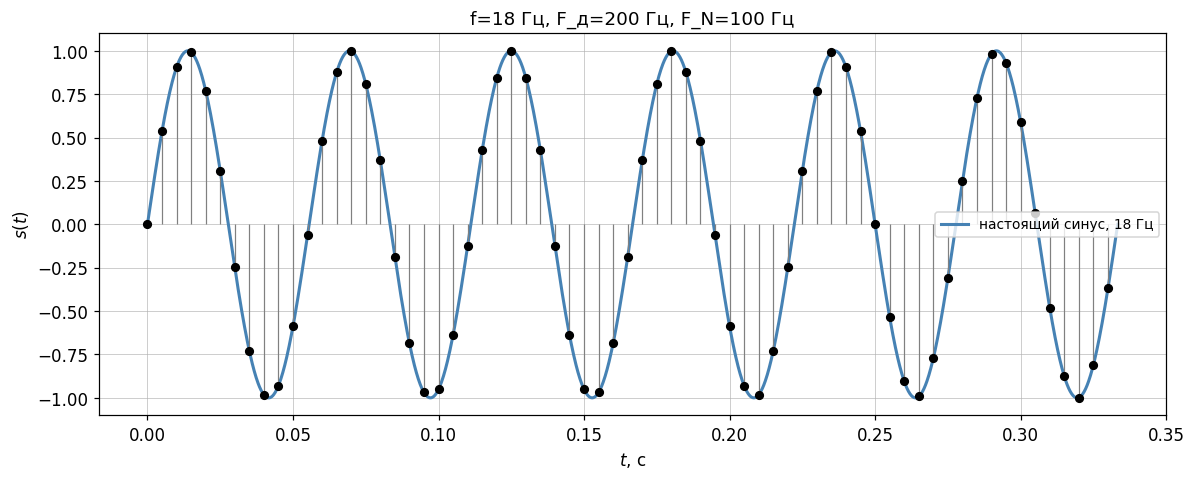

In [3]:
F = 18.0     # частота синуса, Гц
A = 1.0      # амплитуда
FS = 200.0   # частота дискретизации, Гц

describe(F, FS)
plot_sampling(F, FS, A)

Точки садятся ровно на синюю кривую, форма читается — сигнал восстановим.

## Ячейка 4 · Тот же синус, но частота дискретизации мала

Меняем только $F_д$: 25 Гц вместо 200. Найквист падает до 12.5 Гц, а синус
у нас 18 Гц — то есть выше границы.

f    = 18 Гц   — частота синуса
F_д  = 25 Гц   — частота дискретизации
F_N  = 12.5 Гц   — Найквист, F_д/2
f > F_N  →  АЛИАСИНГ: синус выглядит как 7.00 Гц.
           Чтобы увидеть его верно, нужно F_д >= 36 Гц.


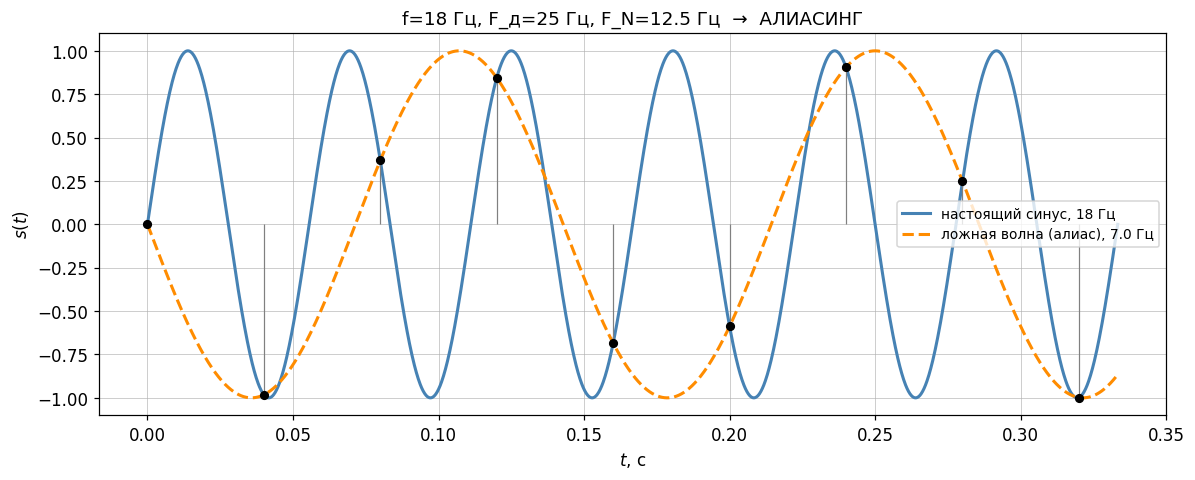

In [4]:
FS_LOW = 25.0

describe(F, FS_LOW)
plot_sampling(F, FS_LOW, A)

Оранжевый пунктир — та самая ложная волна. По одним только чёрным точкам
отличить её от настоящего синуса невозможно: **информация уже потеряна**,
никакой обработкой её не вернуть.

## Ячейка 5 · Где проходит граница

Пройдёмся по частотам дискретизации от малой к большой и посмотрим,
с какой начинается верное отображение.

In [5]:
F_TEST = 18.0
FS_LIST = [20.0, 25.0, 30.0, 36.0, 40.0, 50.0]

print("Синус %g Гц. Минимально нужная F_д = %g Гц.\n" % (F_TEST, 2 * F_TEST))
print("%8s %8s %10s   %s" % ("F_д, Гц", "F_N, Гц", "видимая", "вердикт"))
for fs in FS_LIST:
    ok = F_TEST <= fs / 2
    print("%8g %8g %10.2f   %s"
          % (fs, fs / 2, apparent_freq(F_TEST, fs), "верно" if ok else "алиасинг"))

Синус 18 Гц. Минимально нужная F_д = 36 Гц.

 F_д, Гц  F_N, Гц    видимая   вердикт
      20       10       2.00   алиасинг
      25     12.5       7.00   алиасинг
      30       15      12.00   алиасинг
      36       18      18.00   верно
      40       20      18.00   верно
      50       25      18.00   верно


## Ячейка 6 · Составной сигнал из двух тонов

Реальный сигнал — сумма многих частот. Условие $F_д > 2f$ должно выполняться
для **самой высокой** из них, иначе именно она «свернётся» и испортит картину.

Найквист F_N = 10 Гц

  тон   7.0 Гц (амплитуда 1.0): виден верно
  тон  15.0 Гц (амплитуда 0.8): АЛИАСИНГ → 5.00 Гц

Минимальная F_д для обоих тонов: 30 Гц


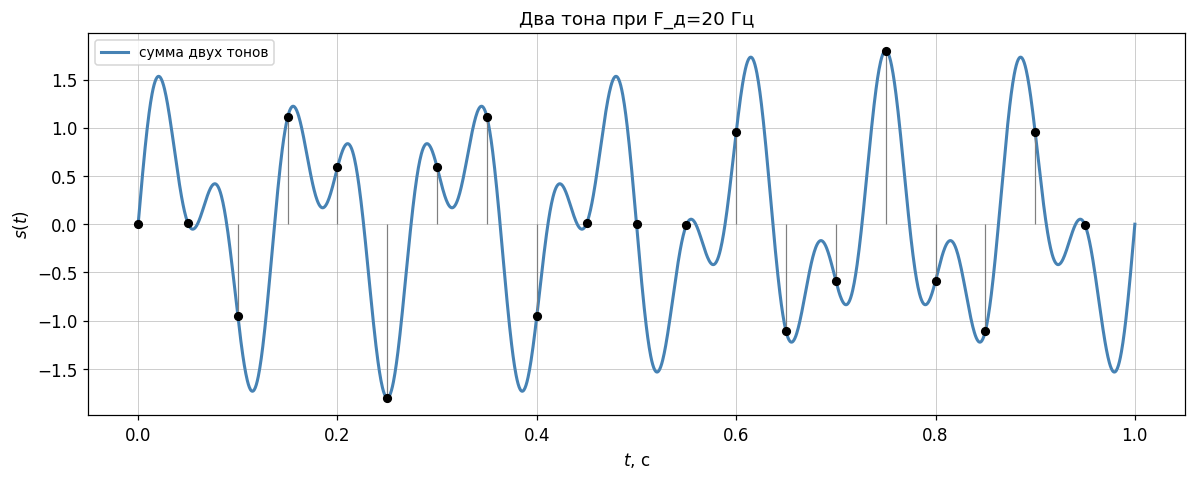

In [6]:
TONES = [(7.0, 1.0), (15.0, 0.8)]   # список (частота Гц, амплитуда)
FS_TWO = 20.0                       # Найквист = 10 Гц: второй тон не проходит

dur = 1.0
t_fine = np.linspace(0, dur, 2000)
t_samp = np.arange(0, dur, 1.0 / FS_TWO)

mix_fine = sum(a * np.sin(2 * np.pi * f * t_fine) for f, a in TONES)
mix_samp = sum(a * np.sin(2 * np.pi * f * t_samp) for f, a in TONES)

print("Найквист F_N = %g Гц\n" % (FS_TWO / 2))
for f, a in TONES:
    status = "виден верно" if f <= FS_TWO / 2 else "АЛИАСИНГ → %.2f Гц" % apparent_freq(f, FS_TWO)
    print("  тон %5.1f Гц (амплитуда %.1f): %s" % (f, a, status))
print("\nМинимальная F_д для обоих тонов: %g Гц" % (2 * max(f for f, _ in TONES)))

fig, ax = plt.subplots()
ax.plot(t_fine, mix_fine, color="steelblue", lw=2, label="сумма двух тонов")
markers, stems, _ = ax.stem(t_samp, mix_samp, linefmt="gray", markerfmt="ko", basefmt=" ")
plt.setp(stems, lw=0.8)
plt.setp(markers, markersize=5)
ax.set(xlabel="$t$, с", ylabel="$s(t)$",
       title="Два тона при F_д=%g Гц" % FS_TWO)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Задания

Ответы проверяй в интерактивной версии — там те же величины на ползунках.

**Часть А · один синус.** Для своей частоты $f$ из таблицы вариантов запиши:
(а) минимальную целую $F_д$, при которой синус ещё виден верно;
(б) частоту Найквиста $F_N = F_д/2$ для неё;
(в) видимую частоту при указанной (малой) $F_д$.

**Часть Б · два тона.** Задай оба тона и указанную $F_д$ и запиши:
(а) частоту Найквиста; (б) какой тон попадает в алиасинг и его видимую
частоту; (в) минимальную $F_д$, при которой оба тона видны верно.

Считать можно прямо здесь — подставь свои числа в ячейки 3–6 и перезапусти их.